In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv('../data/lead Scoring.csv')

In [3]:
df.shape

(9240, 37)

In [4]:
df.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [5]:
df.isnull().sum()

Prospect ID                                         0
Lead Number                                         0
Lead Origin                                         0
Lead Source                                        36
Do Not Email                                        0
Do Not Call                                         0
Converted                                           0
TotalVisits                                       137
Total Time Spent on Website                         0
Page Views Per Visit                              137
Last Activity                                     103
Country                                          2461
Specialization                                   1438
How did you hear about X Education               2207
What is your current occupation                  2690
What matters most to you in choosing a course    2709
Search                                              0
Magazine                                            0
Newspaper Article           

# data cleaning

In [6]:
df_clean = df.copy()

In [7]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 

In [8]:
# check for duplicate values
df_clean.duplicated().sum()

np.int64(0)

In [9]:
#handling placeholders/dummy values
df_clean.replace('Select',pd.NA,inplace=True)

In [10]:
# check for unique values like ID
for col in df_clean.columns:
    print(col,"->",df_clean[col].nunique(),"/",len(df))

Prospect ID -> 9240 / 9240
Lead Number -> 9240 / 9240
Lead Origin -> 5 / 9240
Lead Source -> 21 / 9240
Do Not Email -> 2 / 9240
Do Not Call -> 2 / 9240
Converted -> 2 / 9240
TotalVisits -> 41 / 9240
Total Time Spent on Website -> 1731 / 9240
Page Views Per Visit -> 114 / 9240
Last Activity -> 17 / 9240
Country -> 38 / 9240
Specialization -> 18 / 9240
How did you hear about X Education -> 9 / 9240
What is your current occupation -> 6 / 9240
What matters most to you in choosing a course -> 3 / 9240
Search -> 2 / 9240
Magazine -> 1 / 9240
Newspaper Article -> 2 / 9240
X Education Forums -> 2 / 9240
Newspaper -> 2 / 9240
Digital Advertisement -> 2 / 9240
Through Recommendations -> 2 / 9240
Receive More Updates About Our Courses -> 1 / 9240
Tags -> 26 / 9240
Lead Quality -> 5 / 9240
Update me on Supply Chain Content -> 1 / 9240
Get updates on DM Content -> 1 / 9240
Lead Profile -> 5 / 9240
City -> 6 / 9240
Asymmetrique Activity Index -> 3 / 9240
Asymmetrique Profile Index -> 3 / 9240
Asymme

In [11]:
df_clean.drop(columns=['Prospect ID','Lead Number'],inplace=True)

In [12]:
constant_col=['I agree to pay the amount through cheque','Get updates on DM Content',
              'Update me on Supply Chain Content','Receive More Updates About Our Courses','Magazine']
df_clean.drop(columns=constant_col,inplace=True)

In [13]:
df_clean.shape

(9240, 30)

In [14]:
for col in ['A free copy of Mastering The Interview','Through Recommendations','Digital Advertisement','Newspaper',
            'X Education Forums','Newspaper Article','Search','Converted','Do Not Call','Do Not Email']:
    print(col)
    print(df_clean[col].value_counts(normalize=True))
    print( )

A free copy of Mastering The Interview
A free copy of Mastering The Interview
No     0.687446
Yes    0.312554
Name: proportion, dtype: float64

Through Recommendations
Through Recommendations
No     0.999242
Yes    0.000758
Name: proportion, dtype: float64

Digital Advertisement
Digital Advertisement
No     0.999567
Yes    0.000433
Name: proportion, dtype: float64

Newspaper
Newspaper
No     0.999892
Yes    0.000108
Name: proportion, dtype: float64

X Education Forums
X Education Forums
No     0.999892
Yes    0.000108
Name: proportion, dtype: float64

Newspaper Article
Newspaper Article
No     0.999784
Yes    0.000216
Name: proportion, dtype: float64

Search
Search
No     0.998485
Yes    0.001515
Name: proportion, dtype: float64

Converted
Converted
0    0.61461
1    0.38539
Name: proportion, dtype: float64

Do Not Call
Do Not Call
No     0.999784
Yes    0.000216
Name: proportion, dtype: float64

Do Not Email
Do Not Email
No     0.920563
Yes    0.079437
Name: proportion, dtype: float64

In [15]:
near_const_col=['Do Not Call','Search','Newspaper Article','X Education Forums','Newspaper','Digital Advertisement',
                'Through Recommendations',]
df_clean.drop(columns=near_const_col,inplace=True)

In [16]:
df_clean.shape

(9240, 23)

In [17]:
# handling null values

df_clean.isnull().sum().sort_values(ascending=False)

How did you hear about X Education               7250
Lead Profile                                     6855
Lead Quality                                     4767
Asymmetrique Activity Index                      4218
Asymmetrique Profile Score                       4218
Asymmetrique Profile Index                       4218
Asymmetrique Activity Score                      4218
City                                             3669
Specialization                                   3380
Tags                                             3353
What matters most to you in choosing a course    2709
What is your current occupation                  2690
Country                                          2461
TotalVisits                                       137
Page Views Per Visit                              137
Last Activity                                     103
Lead Source                                        36
Lead Origin                                         0
Do Not Email                

In [18]:
(df_clean.isnull().sum() / len(df_clean) * 100).sort_values(ascending=False)

How did you hear about X Education               78.463203
Lead Profile                                     74.188312
Lead Quality                                     51.590909
Asymmetrique Activity Index                      45.649351
Asymmetrique Profile Score                       45.649351
Asymmetrique Profile Index                       45.649351
Asymmetrique Activity Score                      45.649351
City                                             39.707792
Specialization                                   36.580087
Tags                                             36.287879
What matters most to you in choosing a course    29.318182
What is your current occupation                  29.112554
Country                                          26.634199
TotalVisits                                       1.482684
Page Views Per Visit                              1.482684
Last Activity                                     1.114719
Lead Source                                       0.3896

In [19]:
leakage_and_high_missing = ['How did you hear about X Education', 'Lead Profile', 
                              'Lead Quality', 'Tags']

df_clean.drop(columns=leakage_and_high_missing, inplace=True)

In [20]:
df_clean.shape

(9240, 19)

In [21]:
cols_to_fill_categorical = ['City', 'Specialization', 'What matters most to you in choosing a course',
                              'What is your current occupation', 'Country',
                              'Asymmetrique Activity Index', 'Asymmetrique Profile Index']
for col in cols_to_fill_categorical:
    df_clean[col]=df_clean[col].fillna('Not Specified')

In [22]:
df_clean['Asymmetrique Activity Score'] = df_clean['Asymmetrique Activity Score'].fillna(
    df_clean['Asymmetrique Activity Score'].median())

df_clean['Asymmetrique Profile Score'] = df_clean['Asymmetrique Profile Score'].fillna(
    df_clean['Asymmetrique Profile Score'].median())



In [23]:
df_clean['TotalVisits'] = df_clean['TotalVisits'].fillna(df_clean['TotalVisits'].median())
df_clean['Page Views Per Visit'] = df_clean['Page Views Per Visit'].fillna(df_clean['Page Views Per Visit'].median())
df_clean['Last Activity'] = df_clean['Last Activity'].fillna(df_clean['Last Activity'].mode()[0])
df_clean['Lead Source'] = df_clean['Lead Source'].fillna(df_clean['Lead Source'].mode()[0])

In [24]:
df_clean.isnull().any()

Lead Origin                                      False
Lead Source                                      False
Do Not Email                                     False
Converted                                        False
TotalVisits                                      False
Total Time Spent on Website                      False
Page Views Per Visit                             False
Last Activity                                    False
Country                                          False
Specialization                                   False
What is your current occupation                  False
What matters most to you in choosing a course    False
City                                             False
Asymmetrique Activity Index                      False
Asymmetrique Profile Index                       False
Asymmetrique Activity Score                      False
Asymmetrique Profile Score                       False
A free copy of Mastering The Interview           False
Last Notab

In [25]:
df_clean.isnull().sum().sum()

np.int64(0)

In [26]:
df_clean.shape


(9240, 19)

In [27]:
df_clean.isnull().sum().sum()


np.int64(0)

In [28]:
df_clean.head()

,Lead Origin,Lead Source,Do Not Email,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,Specialization,What is your current occupation,What matters most to you in choosing a course,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,A free copy of Mastering The Interview,Last Notable Activity
0,API,Olark Chat,No,0,0.0,0,0.0,Page Visited on Website,Not Specified,Not Specified,Unemployed,Better Career Prospects,Not Specified,02.Medium,02.Medium,15.0,15.0,No,Modified
1,API,Organic Search,No,0,5.0,674,2.5,Email Opened,India,Not Specified,Unemployed,Better Career Prospects,Not Specified,02.Medium,02.Medium,15.0,15.0,No,Email Opened
2,Landing Page Submission,Direct Traffic,No,1,2.0,1532,2.0,Email Opened,India,Business Administration,Student,Better Career Prospects,Mumbai,02.Medium,01.High,14.0,20.0,Yes,Email Opened
3,Landing Page Submission,Direct Traffic,No,0,1.0,305,1.0,Unreachable,India,Media and Advertising,Unemployed,Better Career Prospects,Mumbai,02.Medium,01.High,13.0,17.0,No,Modified
4,Landing Page Submission,Google,No,1,2.0,1428,1.0,Converted to Lead,India,Not Specified,Unemployed,Better Career Prospects,Mumbai,02.Medium,01.High,15.0,18.0,No,Modified


# EDA

In [29]:
df_clean['Converted'].value_counts()

Converted
0    5679
1    3561
Name: count, dtype: int64

In [30]:
df_clean['Converted'].value_counts(normalize=True) * 100

Converted
0    61.461039
1    38.538961
Name: proportion, dtype: float64

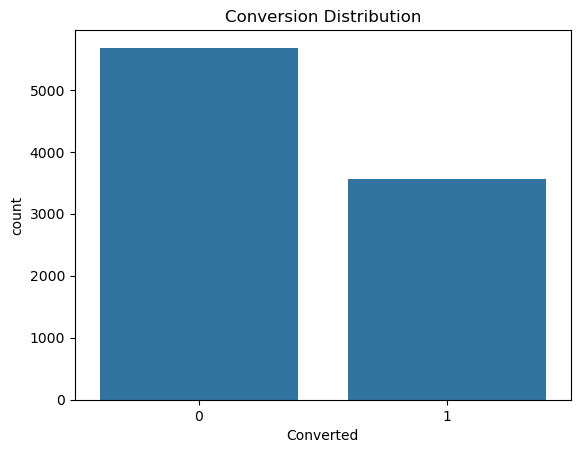

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Converted', data=df_clean)
plt.title('Conversion Distribution')
plt.show()

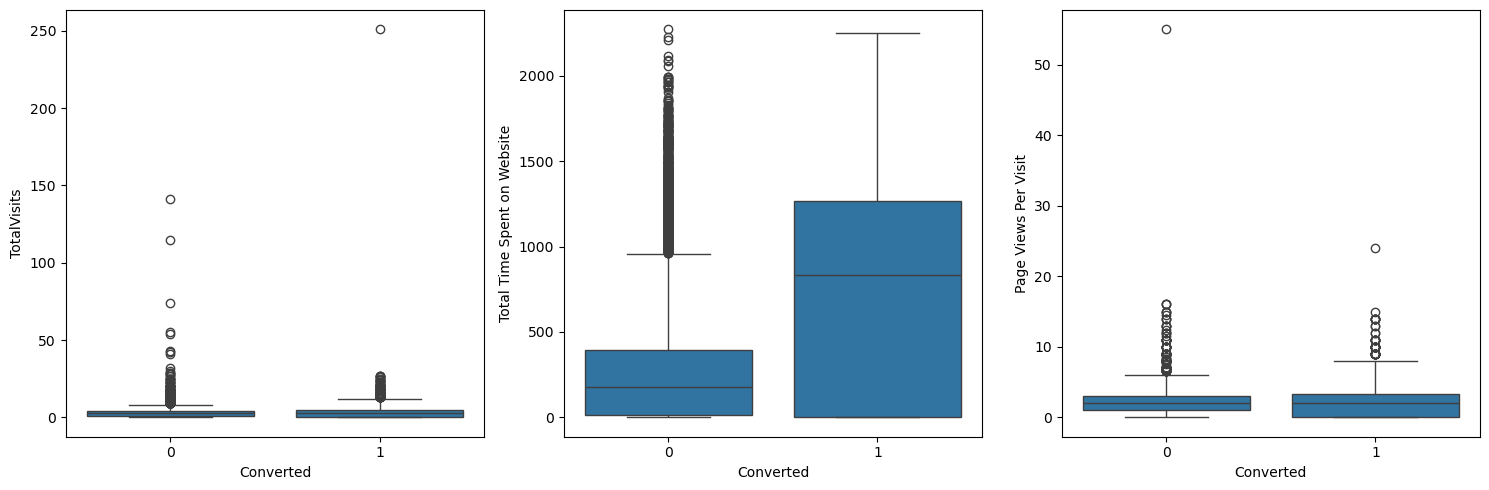

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

sns.boxplot(x='Converted', y='TotalVisits', data=df_clean, ax=axes[0])
sns.boxplot(x='Converted', y='Total Time Spent on Website', data=df_clean, ax=axes[1])
sns.boxplot(x='Converted', y='Page Views Per Visit', data=df_clean, ax=axes[2])

plt.tight_layout()
plt.show()

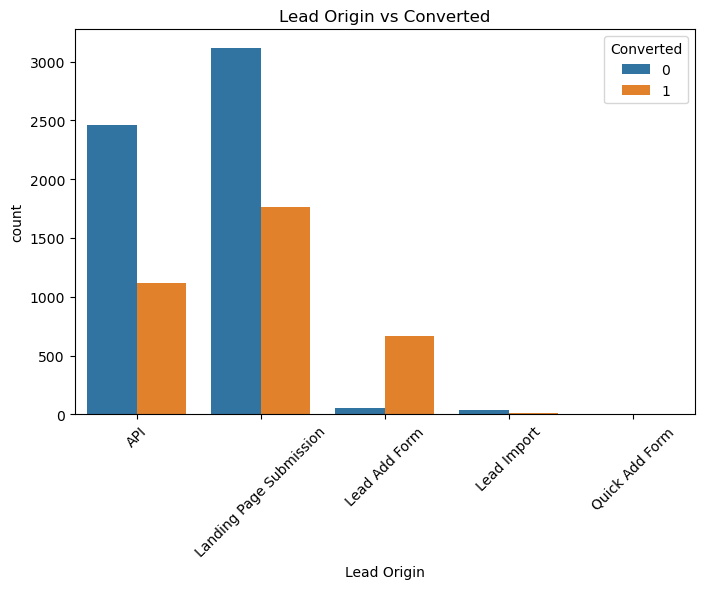

In [33]:
plt.figure(figsize=(8,5))
sns.countplot(x='Lead Origin', hue='Converted', data=df_clean)
plt.title('Lead Origin vs Converted')
plt.xticks(rotation=45)
plt.show()

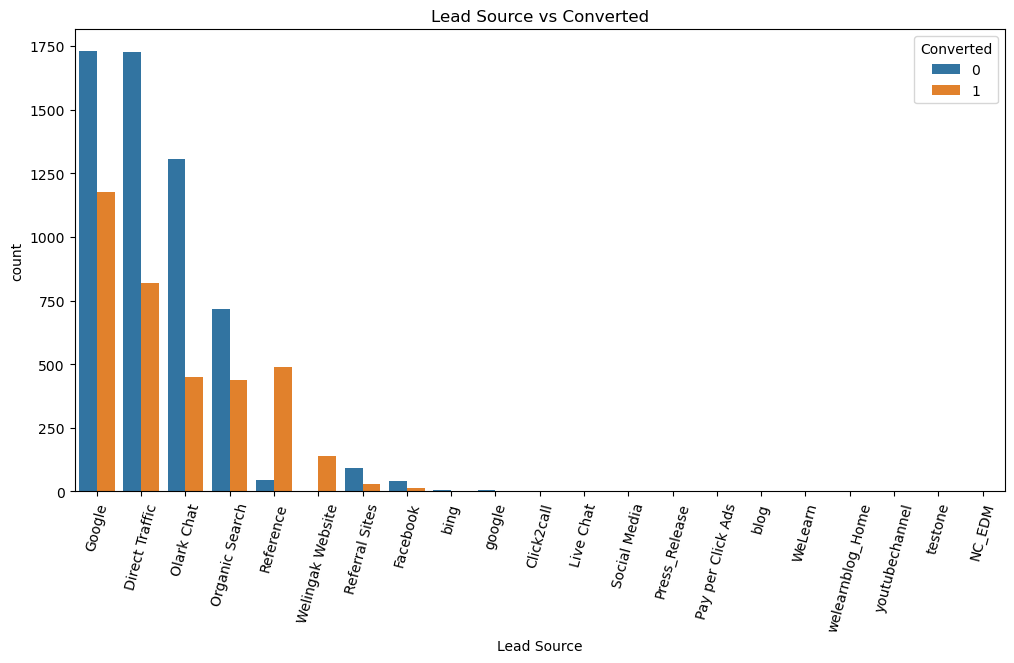

In [34]:
plt.figure(figsize=(12,6))
sns.countplot(x='Lead Source', hue='Converted', data=df_clean, order=df_clean['Lead Source'].value_counts().index)
plt.title('Lead Source vs Converted')
plt.xticks(rotation=75)
plt.show()

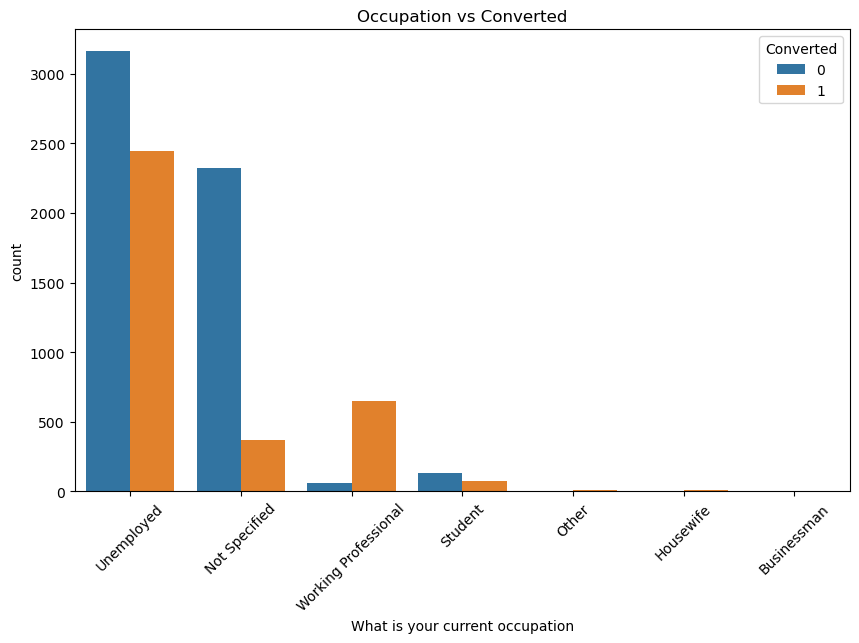

In [35]:
plt.figure(figsize=(10,6))
sns.countplot(x='What is your current occupation', hue='Converted', data=df_clean, 
              order=df_clean['What is your current occupation'].value_counts().index)
plt.title('Occupation vs Converted')
plt.xticks(rotation=45)
plt.show()

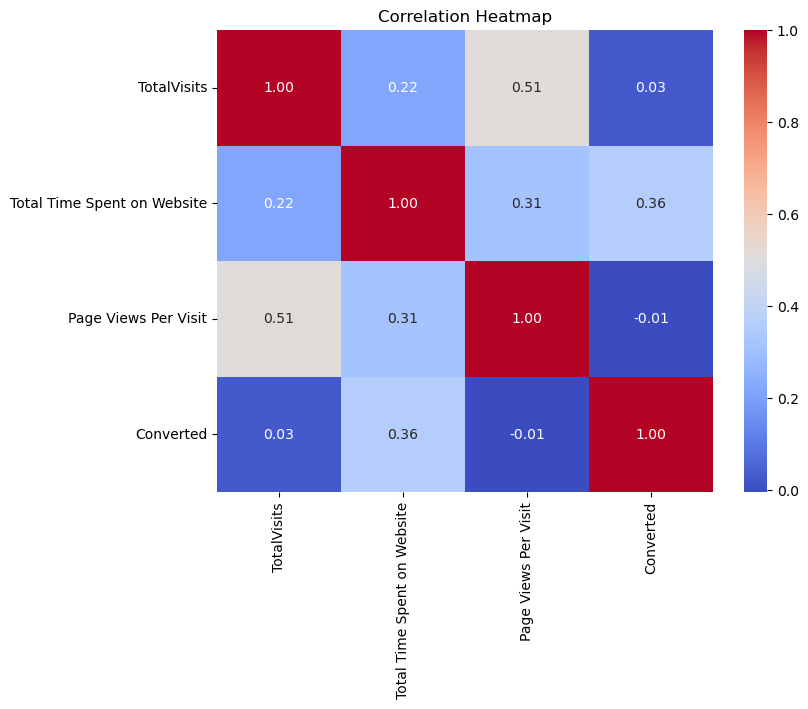

In [36]:
plt.figure(figsize=(8,6))
numeric_cols = ['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit', 'Converted']
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [55]:
remaining_cols = ['Do Not Email', 'Last Activity', 'Country', 'Specialization', 
                   'What matters most to you in choosing a course', 'City',
                   'Last Notable Activity']

for col in remaining_cols:
    print(col)
    print(df_clean.groupby(col)['Converted'].mean().sort_values(ascending=False))
    print()

Do Not Email
Do Not Email
0    0.404773
1    0.160763
Name: Converted, dtype: float64

Last Activity
Last Activity
Approached upfront              1.000000
Email Marked Spam               1.000000
Email Received                  1.000000
Resubscribed to emails          1.000000
Had a Phone Conversation        0.733333
SMS Sent                        0.629144
Email Opened                    0.376836
Unreachable                     0.333333
Email Link Clicked              0.273408
Unsubscribed                    0.262295
Form Submitted on Website       0.241379
Page Visited on Website         0.235937
View in browser link Clicked    0.166667
Converted to Lead               0.126168
Olark Chat Conversation         0.086331
Email Bounced                   0.079755
Visited Booth in Tradeshow      0.000000
Name: Converted, dtype: float64

Country
Country
Denmark                 1.000000
Hong Kong               0.571429
Bahrain                 0.571429
Oman                    0.500000
France 

# feature engeenering

In [37]:
Q1 = df_clean['TotalVisits'].quantile(0.25)
Q3 = df_clean['TotalVisits'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Lower bound: -5.0
Upper bound: 11.0


In [38]:
df_clean['TotalVisits'] = df_clean['TotalVisits'].clip(upper=11.0)

In [39]:
df_clean['TotalVisits'].max()   

11.0

In [40]:
Q1 = df_clean['Page Views Per Visit'].quantile(0.25)
Q3 = df_clean['Page Views Per Visit'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Lower bound: -2.0
Upper bound: 6.0


In [41]:
df_clean['Page Views Per Visit'] = df_clean['Page Views Per Visit'].clip(upper=6.0)

In [42]:
df_clean['Page Views Per Visit'].max()  

6.0

In [43]:
Q1 = df_clean['Total Time Spent on Website'].quantile(0.25)
Q3 = df_clean['Total Time Spent on Website'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Lower bound: -1374.0
Upper bound: 2322.0


In [44]:
df_clean['Total Time Spent on Website'] = df_clean['Total Time Spent on Website'].clip(upper=2322.0)

In [45]:
df_clean['Total Time Spent on Website'].max()  

2272

In [46]:
df_clean['Lead Source'].value_counts()

Lead Source
Google               2904
Direct Traffic       2543
Olark Chat           1755
Organic Search       1154
Reference             534
Welingak Website      142
Referral Sites        125
Facebook               55
bing                    6
google                  5
Click2call              4
Live Chat               2
Social Media            2
Press_Release           2
Pay per Click Ads       1
blog                    1
WeLearn                 1
welearnblog_Home        1
youtubechannel          1
testone                 1
NC_EDM                  1
Name: count, dtype: int64

In [47]:
source_counts = df_clean['Lead Source'].value_counts()
rare_sources = source_counts[source_counts < 100].index
df_clean['Lead Source'] = df_clean['Lead Source'].replace(rare_sources, 'Other')

In [48]:
for col in ['Specialization', 'City', 'What is your current occupation']:
    counts = df_clean[col].value_counts()
    rare = counts[counts < 100].index
    df_clean[col] = df_clean[col].replace(rare, 'Other')

In [49]:
binary_cols = ['Do Not Email', 'A free copy of Mastering The Interview']
for col in binary_cols:
    df_clean[col] = df_clean[col].map({'Yes': 1, 'No': 0})

In [50]:
categorical_cols = df_clean.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('Converted') if 'Converted' in categorical_cols else None

df_final = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

In [51]:
from sklearn.model_selection import train_test_split

X = df_final.drop('Converted', axis=1)
y = df_final['Converted']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [53]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

In [54]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 19 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Lead Origin                                    9240 non-null   object 
 1   Lead Source                                    9240 non-null   object 
 2   Do Not Email                                   9240 non-null   int64  
 3   Converted                                      9240 non-null   int64  
 4   TotalVisits                                    9240 non-null   float64
 5   Total Time Spent on Website                    9240 non-null   int64  
 6   Page Views Per Visit                           9240 non-null   float64
 7   Last Activity                                  9240 non-null   object 
 8   Country                                        9240 non-null   object 
 9   Specialization                                 9240 

# Modeling

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

models = {
    'Logistic Regression': LogisticRegression(),
    'SVM': SVC(),
    'KNN': KNeighborsClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train_resampled, y_train_resampled)
    preds = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    
    results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}
    
    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, preds))
    print()

--- Logistic Regression ---
Accuracy: 0.8149
Precision: 0.7428
Recall: 0.7949
F1 Score: 0.7680
Confusion Matrix:
[[940 196]
 [146 566]]

--- SVM ---
Accuracy: 0.8225
Precision: 0.7540
Recall: 0.8006
F1 Score: 0.7766
Confusion Matrix:
[[950 186]
 [142 570]]

--- KNN ---
Accuracy: 0.7370
Precision: 0.6355
Recall: 0.7444
F1 Score: 0.6856
Confusion Matrix:
[[832 304]
 [182 530]]



In [57]:
from sklearn.ensemble import RandomForestClassifier

models['Random Forest'] = RandomForestClassifier(random_state=42)

# same loop se train/evaluate kar sakti ho jo pehle chalaya tha
model = models['Random Forest']
model.fit(X_train_resampled, y_train_resampled)
preds = model.predict(X_test_scaled)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, preds))
print("Precision:", precision_score(y_test, preds))
print("Recall:", recall_score(y_test, preds))
print("F1:", f1_score(y_test, preds))
print(confusion_matrix(y_test, preds))

Random Forest
Accuracy: 0.8371212121212122
Precision: 0.7850208044382802
Recall: 0.7949438202247191
F1: 0.7899511514305653
[[981 155]
 [146 566]]


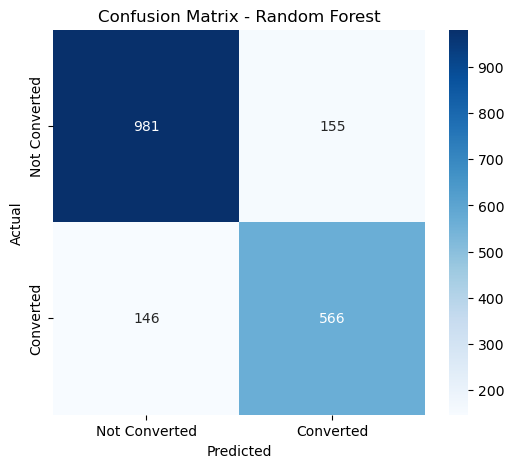

In [59]:
from sklearn.metrics import confusion_matrix

model = models['Random Forest']
preds = model.predict(X_test_scaled)

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Converted', 'Converted'], 
            yticklabels=['Not Converted', 'Converted'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

In [58]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

joblib.dump(models['Random Forest'], '../models/best_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

print("Model and scaler saved successfully!")

Model and scaler saved successfully!
